# **Space X Falcon 9 First Stage Landing Prediction**


## STEP 1 - Install Libraries (only needed in Colab)

In [2]:
# Run this cell first - installs all required libraries
!pip install pandas numpy seaborn scikit-learn matplotlib --quiet
print('All libraries installed!')

All libraries installed!


## STEP 2 - Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

print('All libraries imported!')

All libraries imported!


## STEP 3 - Confusion Matrix Function

In [5]:
def plot_confusion_matrix(y, y_predict):
    
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y, y_predict)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax, fmt='g')
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['did not land', 'land'])
    ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()

print('Confusion matrix function ready!')

Confusion matrix function ready!


## STEP 4 - Load Data (Fixed - No fetch needed!)

In [6]:
# Load dataset_part_2 (contains Class/target column)
URL1 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv'
data = pd.read_csv(URL1)
print('data loaded! Shape:', data.shape)
data.head()

data loaded! Shape: (90, 18)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [7]:
# Load dataset_part_3 (contains features X)
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
X = pd.read_csv(URL2)
print('X loaded! Shape:', X.shape)
X.head()

X loaded! Shape: (90, 83)


,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


## TASK 1 - Create Y array from Class column

In [8]:
# Create numpy array from Class column
Y = data['Class'].to_numpy()

print('Y array:', Y)
print('Type:', type(Y))
print('Shape:', Y.shape)
print('Unique values:', np.unique(Y))
print('\n0 = Failed landing')
print('1 = Successful landing')

Y array: [0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0 1
 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1]
Type: <class 'numpy.ndarray'>
Shape: (90,)
Unique values: [0 1]

0 = Failed landing
1 = Successful landing


## TASK 2 - Standardize the data X

In [9]:
# Standardize features using StandardScaler
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

print(' X standardized!')
print('X shape:', X.shape)
print('Mean (should be ~0):', X.mean().round(2))
print('Std  (should be ~1):', X.std().round(2))

 X standardized!
X shape: (90, 83)
Mean (should be ~0): -0.0
Std  (should be ~1): 1.0


## TASK 3 - Split data into Training and Test sets

In [10]:
# Split data - 80% train, 20% test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=2
)

print(' Data split complete!')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'Y_test shape:  {Y_test.shape}')

 Data split complete!
X_train shape: (72, 83)
X_test shape:  (18, 83)
Y_train shape: (72,)
Y_test shape:  (18,)


In [11]:
# Check test samples
print('Number of test samples:', Y_test.shape)

Number of test samples: (18,)


## TASK 4 - Logistic Regression with GridSearchCV

In [12]:
parameters = {'C': [0.01, 0.1, 1],
              'penalty': ['l2'],
              'solver': ['lbfgs']}

lr = LogisticRegression(max_iter=1000)
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

print('Logistic Regression trained!')
print('Tuned hyperparameters (best parameters):', logreg_cv.best_params_)
print('Accuracy (train/validation):', logreg_cv.best_score_)

Logistic Regression trained!
Tuned hyperparameters (best parameters): {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy (train/validation): 0.8464285714285713


## TASK 5 - Logistic Regression Test Accuracy & Confusion Matrix

In [13]:
# Calculate accuracy on test data
logreg_score = logreg_cv.score(X_test, Y_test)
print('Logistic Regression Test Accuracy:', logreg_score)
print(f'Accuracy: {logreg_score*100:.1f}%')

Logistic Regression Test Accuracy: 0.8333333333333334
Accuracy: 83.3%


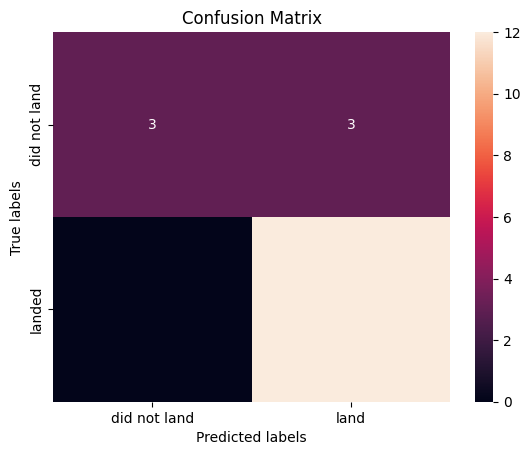

In [14]:
# Plot confusion matrix
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

## TASK 6 - SVM with GridSearchCV

In [15]:
parameters = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}

svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

print('SVM trained!')
print('Tuned hyperparameters (best parameters):', svm_cv.best_params_)
print('Accuracy (train/validation):', svm_cv.best_score_)

SVM trained!
Tuned hyperparameters (best parameters): {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
Accuracy (train/validation): 0.8482142857142856


## TASK 7 - SVM Test Accuracy & Confusion Matrix

In [16]:
# Calculate accuracy on test data
svm_score = svm_cv.score(X_test, Y_test)
print('SVM Test Accuracy:', svm_score)
print(f'Accuracy: {svm_score*100:.1f}%')

SVM Test Accuracy: 0.8333333333333334
Accuracy: 83.3%


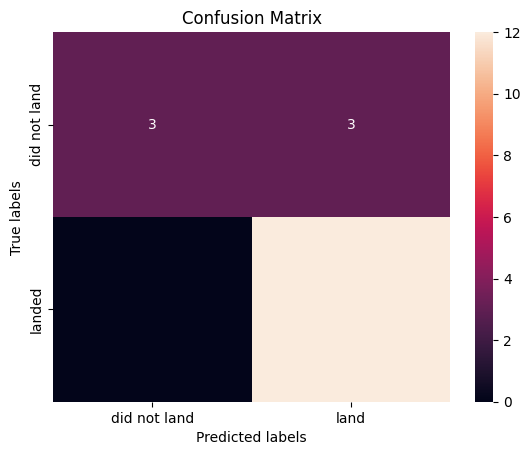

In [17]:
# Plot confusion matrix
yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

## TASK 8 - Decision Tree with GridSearchCV

In [18]:
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2*n for n in range(1, 10)],
              'max_features': ['auto', 'sqrt'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

print('Decision Tree trained!')
print('Tuned hyperparameters (best parameters):', tree_cv.best_params_)
print('Accuracy (train/validation):', tree_cv.best_score_)

Decision Tree trained!
Tuned hyperparameters (best parameters): {'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'splitter': 'random'}
Accuracy (train/validation): 0.8732142857142857


C:\Users\tpriy\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\tpriy\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\tpriy\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\tpriy\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py", line 436, in _validate_params
    v

## TASK 9 - Decision Tree Test Accuracy & Confusion Matrix

In [19]:
# Calculate accuracy on test data
tree_score = tree_cv.score(X_test, Y_test)
print('Decision Tree Test Accuracy:', tree_score)
print(f'Accuracy: {tree_score*100:.1f}%')

Decision Tree Test Accuracy: 0.7222222222222222
Accuracy: 72.2%


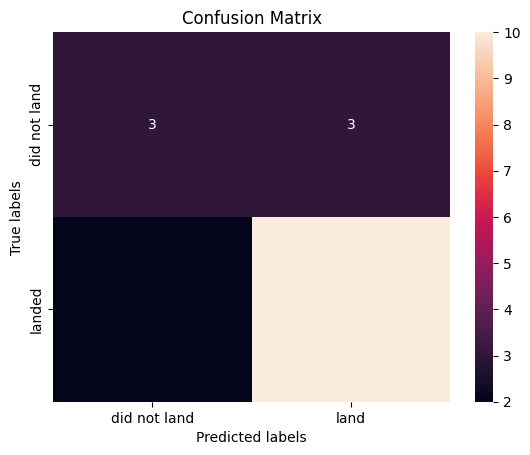

In [20]:
# Plot confusion matrix
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

## TASK 10 - KNN with GridSearchCV

In [21]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}

KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

print(' KNN trained!')
print('Tuned hyperparameters (best parameters):', knn_cv.best_params_)
print('Accuracy (train/validation):', knn_cv.best_score_)

 KNN trained!
Tuned hyperparameters (best parameters): {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
Accuracy (train/validation): 0.8482142857142858


## TASK 11 - KNN Test Accuracy & Confusion Matrix

In [22]:
# Calculate accuracy on test data
knn_score = knn_cv.score(X_test, Y_test)
print('KNN Test Accuracy:', knn_score)
print(f'Accuracy: {knn_score*100:.1f}%')

KNN Test Accuracy: 0.8333333333333334
Accuracy: 83.3%


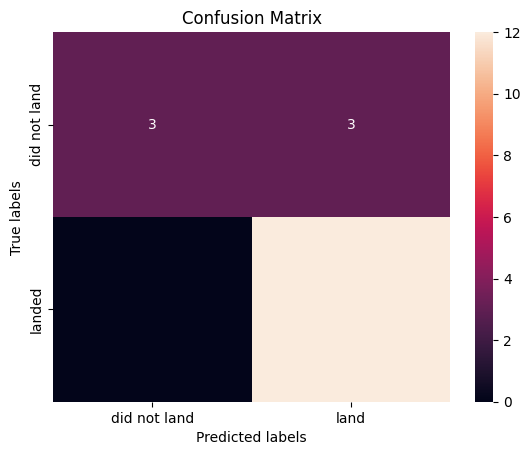

In [23]:
# Plot confusion matrix
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

## TASK 12 - Find Best Model

In [24]:
# Compare all models
results = {
    'Logistic Regression': logreg_cv.score(X_test, Y_test),
    'SVM':                 svm_cv.score(X_test, Y_test),
    'Decision Tree':       tree_cv.score(X_test, Y_test),
    'KNN':                 knn_cv.score(X_test, Y_test)
}


print('      FINAL MODEL COMPARISON')
print('='*50)
for name, score in results.items():
    print(f'  {name:<25} {score:.4f} ({score*100:.1f}%)')

best_model = max(results, key=results.get)

print(f'BEST MODEL : {best_model}')
print(f'ACCURACY   : {results[best_model]*100:.1f}%')


      FINAL MODEL COMPARISON
  Logistic Regression       0.8333 (83.3%)
  SVM                       0.8333 (83.3%)
  Decision Tree             0.7222 (72.2%)
  KNN                       0.8333 (83.3%)
BEST MODEL : Logistic Regression
ACCURACY   : 83.3%


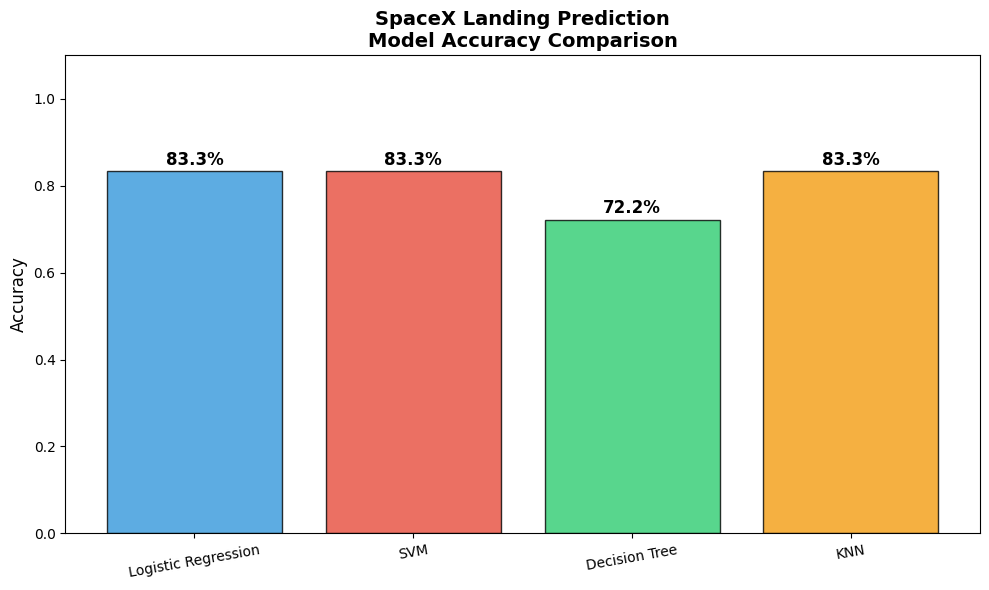

Chart saved!


In [25]:
# Plot bar chart comparison
import matplotlib.pyplot as plt

names = list(results.keys())
scores = list(results.values())
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

plt.figure(figsize=(10, 6))
bars = plt.bar(names, scores, color=colors, alpha=0.8, edgecolor='black')

for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{score*100:.1f}%',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

plt.title('SpaceX Landing Prediction\nModel Accuracy Comparison', 
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Chart saved!')


















